In [1]:
import matplotlib.pyplot as plt
import scienceplots
# plt.style.use('science')
plt.style.use(['science', 'nature', 'grid'])

from matplotlib.lines import Line2D

import string
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd
import json

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [2]:
WIDTH = 6.0 
HEIGHT = 2.5 #5.0

plt.rcParams.update({
    "figure.figsize": (WIDTH, HEIGHT),
    "font.size": 10,           # Matches thesis 10pt
    "axes.labelsize": 10,
    "legend.fontsize": 8,      # Slightly smaller for legends
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1,
    "lines.markersize": 4,
    "savefig.bbox": 'tight',   # Ensures no labels are cut off
    "savefig.pad_inches": 0.05
})

labels = string.ascii_lowercase

In [26]:
# Solver and simulation parameters
M_vector = [4, 5, 6, 7, 8]
closure_vec = ["ExtGram"]#!["Gram", "ExtGram", "Grad"]
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level = 8
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

x_lower = -2.0
x_upper = 2.0

# BGK
N = 1_000 # BGK
base_tree_level_bgk = 8
x_left_BGK = -5.0
x_right_BGK = 5.0
c_L = -6.0
c_R = 6.0

In [4]:
# file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

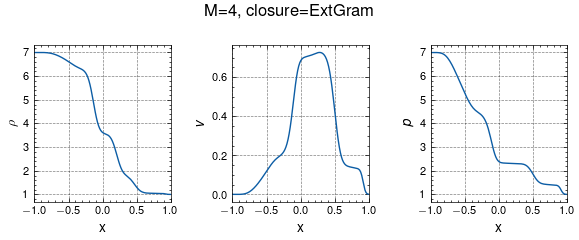

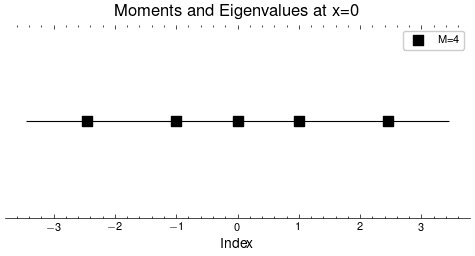

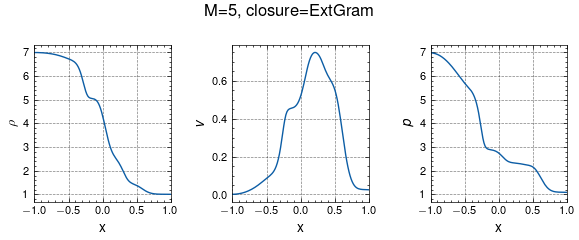

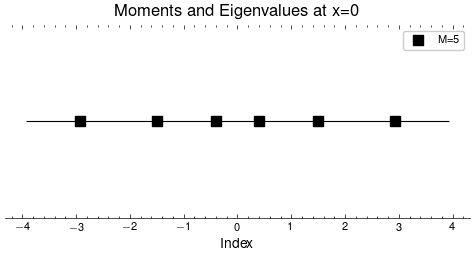

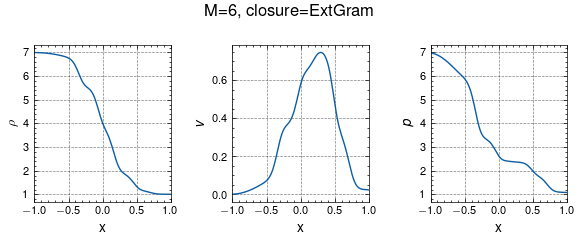

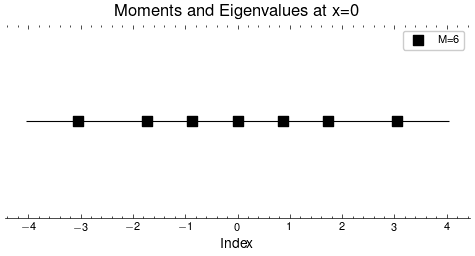

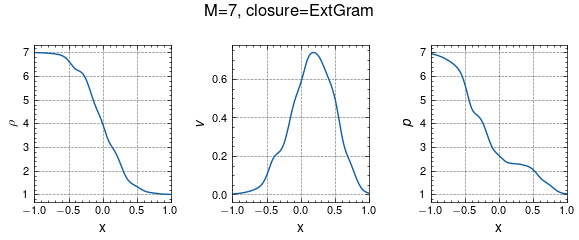

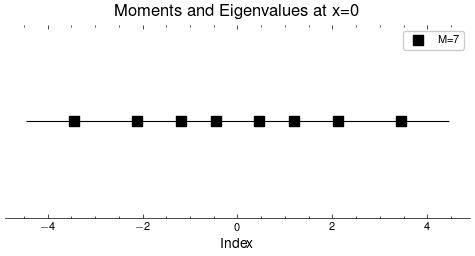

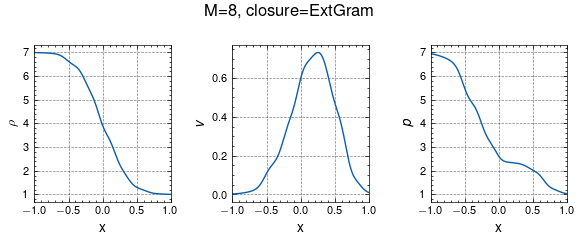

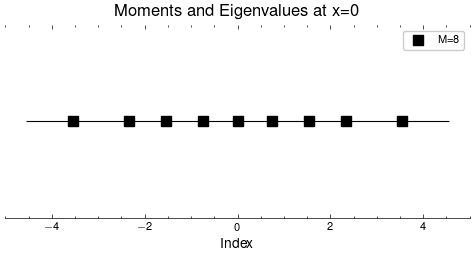

In [18]:
for closure in closure_vec:
    for M in M_vector:
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        fig, axs = plt.subplots(1, 3)
        fig.suptitle(f"M={M}, closure={closure}")
        [ax.set_xlim(-1, 1) for ax in axs]
        [ax.set_xlabel('x') for ax in axs]
        [ax.set_ylabel(label) for ax, label in zip(axs, ['$\\rho$', '$v$', '$p$'])]

        axs[0].plot(x, rho)
        axs[1].plot(x, v)
        axs[2].plot(x, p)
        fig.tight_layout()

        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)
        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

        fig, axs = plt.subplots()
        # axs.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label='Eigenvalues at x=0')
        axs.hlines(
            0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
            colors='black', linewidth=0.8, zorder=1
        )
        axs.scatter(
            eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
            marker='s', s=60, color='black', label=f'M={M}', zorder=2
        )
        axs.get_yaxis().set_visible(False)
        for spine in ['left', 'right', 'top']:
            axs.spines[spine].set_visible(False)
        axs.grid()
        axs.get_yaxis().set_visible(False) # Hides ticks and label
        axs.spines['left'].set_visible(False) # Hides the left vertical line
        axs.spines['right'].set_visible(False)
        axs.spines['top'].set_visible(False)
        axs.set_xlabel('Index')
        axs.set_ylabel('Value')
        axs.set_title('Moments and Eigenvalues at x=0')
        axs.legend()
        plt.show()

In [22]:
colors = ['blue', 'orange', 'green', 'red', 'purple']

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_36252/1694945796.py:58: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


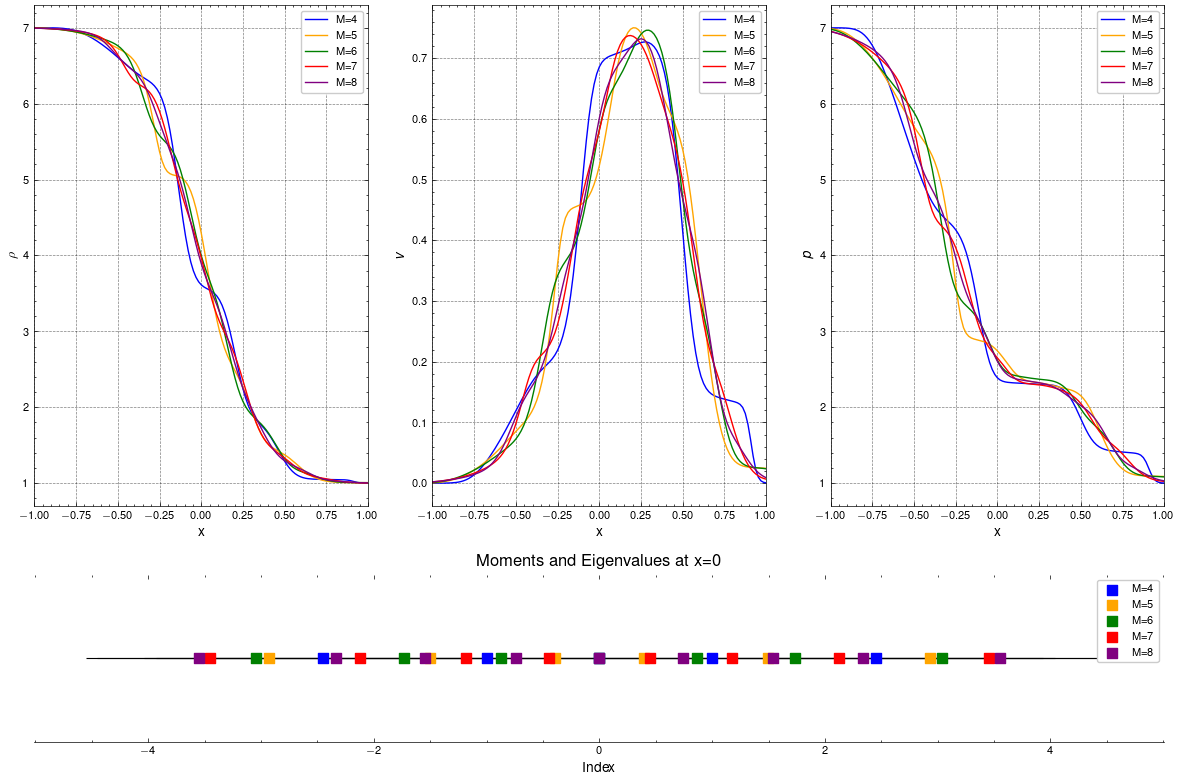

In [23]:
for closure in closure_vec:
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[3, 1])
    
    ax_rho = fig.add_subplot(gs[0, 0])
    ax_v   = fig.add_subplot(gs[0, 1])
    ax_p   = fig.add_subplot(gs[0, 2])
    ax_eig = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    
    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
    for i, M in enumerate(M_vector):
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)
        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

        ax_eig.hlines(
            0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
            colors='black', linewidth=0.8, zorder=1
        )
        ax_eig.scatter(
            eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
            marker='s', s=60, color=colors[i], label=f'M={M}', zorder=2
        )
        ax_eig.get_yaxis().set_visible(False)
        for spine in ['left', 'right', 'top']:
            ax_eig.spines[spine].set_visible(False)
        ax_eig.grid()
        ax_eig.get_yaxis().set_visible(False) # Hides ticks and label
        ax_eig.spines['left'].set_visible(False) # Hides the left vertical line
        ax_eig.spines['right'].set_visible(False)
        ax_eig.spines['top'].set_visible(False)
        ax_eig.set_xlabel('Index')
        ax_eig.set_ylabel('Value')
        ax_eig.set_title('Moments and Eigenvalues at x=0')
    
    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()
    ax_eig.legend()

    fig.tight_layout()
    fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_36252/1203848924.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


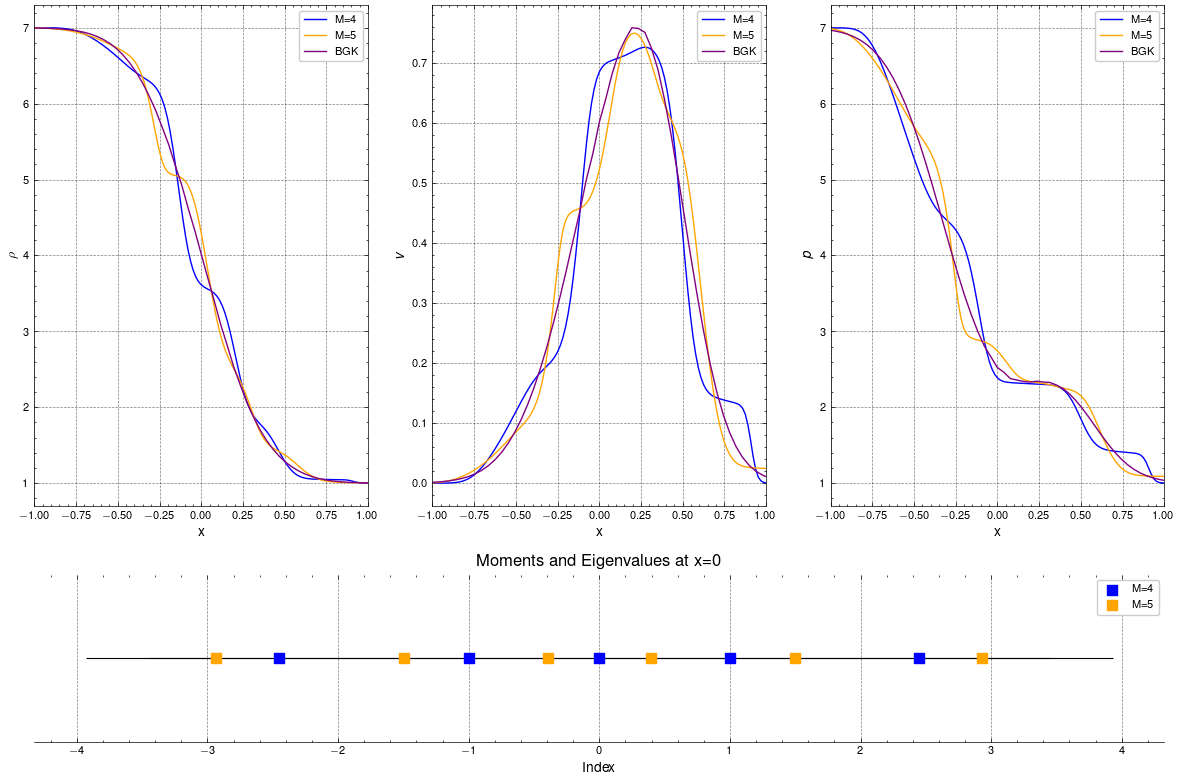

In [29]:
for closure in closure_vec:
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[3, 1])
    
    ax_rho = fig.add_subplot(gs[0, 0])
    ax_v   = fig.add_subplot(gs[0, 1])
    ax_p   = fig.add_subplot(gs[0, 2])
    ax_eig = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    
    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
    for i, M in enumerate([4, 5]):
        # Moments
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # Eigenvalues
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)
        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

        ax_eig.hlines(
            0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
            colors='black', linewidth=0.8, zorder=1
        )
        ax_eig.scatter(
            eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
            marker='s', s=60, color=colors[i], label=f'M={M}', zorder=2
        )
        ax_eig.get_yaxis().set_visible(False)
        for spine in ['left', 'right', 'top']:
            ax_eig.spines[spine].set_visible(False)
        ax_eig.grid()
        ax_eig.get_yaxis().set_visible(False) # Hides ticks and label
        ax_eig.spines['left'].set_visible(False) # Hides the left vertical line
        ax_eig.spines['right'].set_visible(False)
        ax_eig.spines['top'].set_visible(False)
        ax_eig.set_xlabel('Index')
        ax_eig.set_ylabel('Value')
        ax_eig.set_title('Moments and Eigenvalues at x=0')

    # BGK
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

    x_bgk = data_bgk['x'].to_numpy()

    rho_bgk = data_bgk['rho'].to_numpy()
    ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

    v_bgk = data_bgk['v'].to_numpy()
    ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')
    
    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()
    ax_eig.legend()

    fig.tight_layout()
    fig.show()

/var/folders/v_/5q1gkdc53z34pdsfnpkx2t340000gn/T/ipykernel_36252/775767641.py:75: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


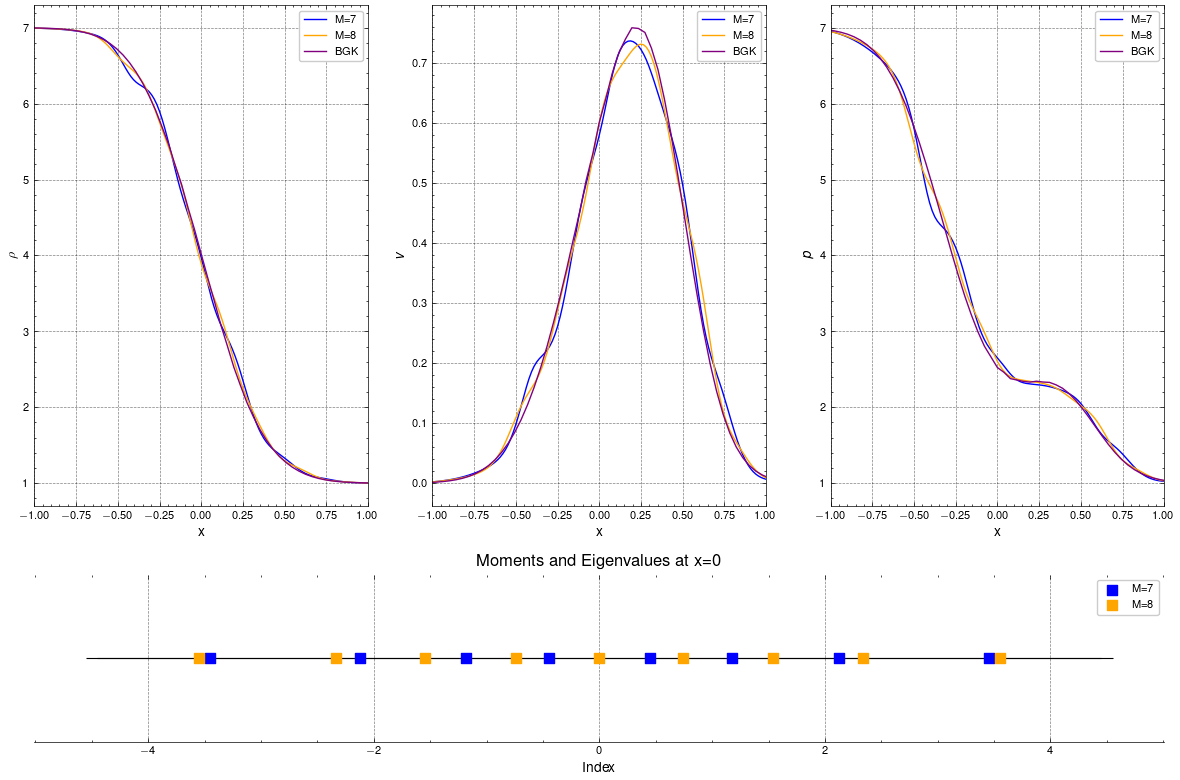

In [30]:
for closure in closure_vec:
    fig = plt.figure(figsize=(12, 8))
    gs = fig.add_gridspec(2, 3, height_ratios=[3, 1])
    
    ax_rho = fig.add_subplot(gs[0, 0])
    ax_v   = fig.add_subplot(gs[0, 1])
    ax_p   = fig.add_subplot(gs[0, 2])
    ax_eig = fig.add_subplot(gs[1, :]) # Span all columns for the eigenvalue line
    
    [ax.set_xlim(-1, 1) for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_xlabel('x') for ax in [ax_rho, ax_v, ax_p]]
    [ax.set_ylabel(label) for ax, label in zip([ax_rho, ax_v, ax_p], ['$\\rho$', '$v$', '$p$'])]
    for i, M in enumerate([7, 8]):
        # Moments
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"

        x, u, _ = sol_final(file)
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = (u[:, 2] - rho * v**2) # ?1/2 * u[:, 2]
        theta = p / rho

        ax_rho.plot(x, rho, color=colors[i], label=f'M={M}')
        ax_v.plot(x, v, color=colors[i], label=f'M={M}')
        ax_p.plot(x, p, color=colors[i], label=f'M={M}')

        # Eigenvalues
        file = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_eigenvalues.csv"
        df = pd.read_csv(file)
        x_dest = 0.0
        x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
        eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

        ax_eig.hlines(
            0, xmin=min(eigenvalues_at_x)-1, xmax=max(eigenvalues_at_x)+1, 
            colors='black', linewidth=0.8, zorder=1
        )
        ax_eig.scatter(
            eigenvalues_at_x, np.zeros_like(eigenvalues_at_x), 
            marker='s', s=60, color=colors[i], label=f'M={M}', zorder=2
        )
        ax_eig.get_yaxis().set_visible(False)
        for spine in ['left', 'right', 'top']:
            ax_eig.spines[spine].set_visible(False)
        ax_eig.grid()
        ax_eig.get_yaxis().set_visible(False) # Hides ticks and label
        ax_eig.spines['left'].set_visible(False) # Hides the left vertical line
        ax_eig.spines['right'].set_visible(False)
        ax_eig.spines['top'].set_visible(False)
        ax_eig.set_xlabel('Index')
        ax_eig.set_ylabel('Value')
        ax_eig.set_title('Moments and Eigenvalues at x=0')

    # BGK
    data_bgk = pd.read_csv(f'../out/Riemann1D/BGK/bgk_solution_N{N}_c_l{c_L}_c_u{c_R}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_bgk}_polydeg{polydeg}_x_left{x_left_BGK}_x_right{x_right_BGK}_rho_v_p.csv')

    x_bgk = data_bgk['x'].to_numpy()

    rho_bgk = data_bgk['rho'].to_numpy()
    ax_rho.plot(x_bgk, rho_bgk, color=colors[4], label='BGK')

    v_bgk = data_bgk['v'].to_numpy()
    ax_v.plot(x_bgk, v_bgk, color=colors[4], label='BGK')

    p_bgk = data_bgk['p'].to_numpy()
    theta_bgk = p_bgk / rho_bgk
    ax_p.plot(x_bgk, p_bgk, color=colors[4], label='BGK')
    
    ax_rho.legend()
    ax_v.legend()
    ax_p.legend()
    ax_eig.legend()

    fig.tight_layout()
    fig.show()

In [ ]:
file = '../out/Riemann1D/eigenvalues.csv'
df = pd.read_csv(file)
df.head()

,x_vector,eigenvalue,moments
0,-2.000000,-2.932270,"[6.999999999999999, -6.356026815979021e-15, 7...."
1,-1.992172,-1.498825,"[6.999999999999999, -6.356026815979021e-15, 7...."
2,-1.984344,-0.394099,"[6.999999999999999, -6.356026815979021e-15, 7...."
3,-1.976517,0.394100,"[6.999999999999999, -6.356026815979021e-15, 7...."
4,-1.968689,1.498824,"[6.999999999999999, -6.356026815979021e-15, 7...."


: 

In [ ]:
x_dest = 0.0
x_idx = (np.abs(df['x_vector'] - x_dest)).argmin()
eigenvalues_at_x = df['eigenvalue'][x_idx:x_idx+M+1]

: 

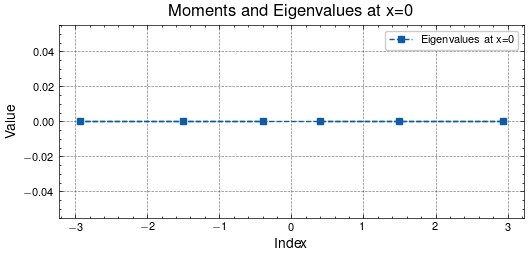

: 

In [ ]:
plt.subplots()
plt.plot(eigenvalues_at_x, [0]*len(eigenvalues_at_x), 's--', label='Eigenvalues at x=0')
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Moments and Eigenvalues at x=0')
plt.legend()
plt.show()

: 